# Assignment 5 - Question 1: NN Basics

## I. Fitting Data (8 points)


### Step 0: Review of libraries and installation

In [1]:
import Pkg
using Pkg

Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("StatsModels")
Pkg.add("GLM")
Pkg.add("Random")
Pkg.add("MLDataUtils")
Pkg.add("MLBase")
Pkg.add("FixedEffectModels")
Pkg.add("Lasso")
Pkg.add("MLJ")
Pkg.add("DecisionTree")
Pkg.add("RData")
Pkg.add("GLMNet")
Pkg.add("PrettyTables")
Pkg.add("MLJScikitLearnInterface")
Pkg.add("MLJFlux")
Pkg.add("Flux")

   Resolving package versions...
  No Changes to `C:\Users\User\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\User\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\User\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\User\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\User\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\User\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\User\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\User\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\User\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\User\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
   Installed StatsFuns ──────────────── v1.5.2
   Installed GR_jll ─────────────────── 

[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:02
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:01
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:02
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #18), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:02


┌──────────┬───────────┐
│    model │       mse │
│   String │   Float64 │
├──────────┼───────────┤
│ logistic │ 0.0408797 │
│     tanh │ 0.0389594 │
│     relu │ 0.0368535 │
│    mixed │ 0.0398134 │
└──────────┴───────────┘


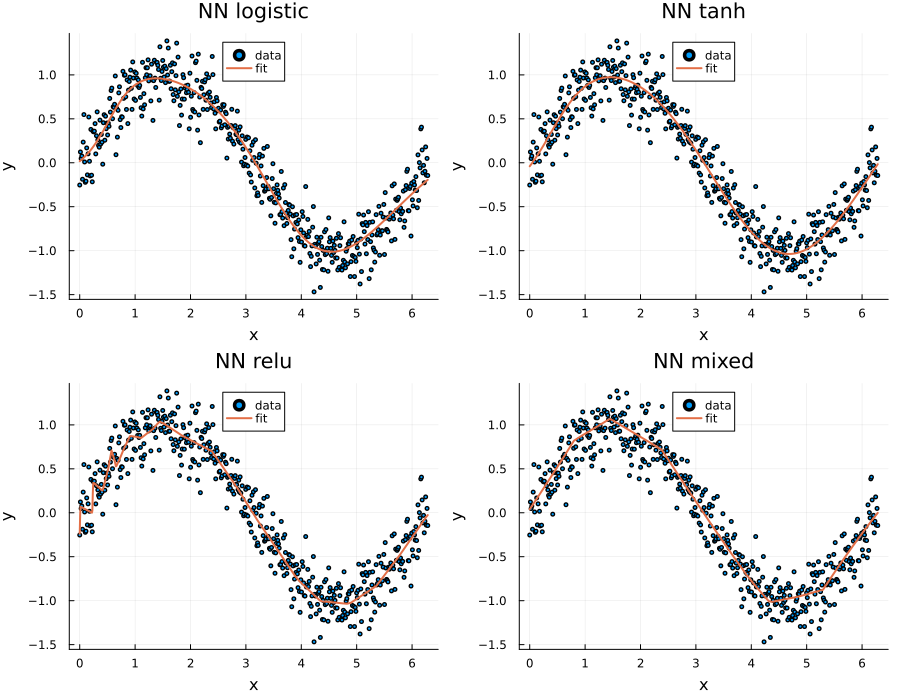

In [13]:
using MLJ, MLJFlux, Flux, DataFrames, Random, PrettyTables, Plots

Random.seed!(7)
n = 500
x = range(0, 2π; length=n)
ϵ = 0.20 .* randn(n)
y = @. sin(x) + ϵ

df = DataFrame(x = collect(x), y = y)
X  = select(df, :x)
yv = df.y

xgrid = collect(range(0, 2π; length=800))
Xgrid = DataFrame(x = xgrid)

const n_in  = size(Matrix(X), 2)  # = 1
const n_out = 1


function builder_by_activation(activation::Function; n_hidden_layers::Int=3, n_hidden_units::Int=50)
    @assert n_hidden_layers ≥ 1 "n_hidden_layers debe ser ≥ 1"
    layers = Any[ Dense(n_in, n_hidden_units, activation) ]
    for _ in 2:n_hidden_layers
        push!(layers, Dense(n_hidden_units, n_hidden_units, activation))
    end
    push!(layers, Dense(n_hidden_units, n_out)) 
    return MLJFlux.@builder Chain(layers...)
end

function fit_nn(activation; name::AbstractString,
                n_hidden_layers::Int=3, n_hidden_units::Int=50,
                epochs::Int=1500, η::Float64=1e-3, batch_size::Int=128)

    builder = builder_by_activation(activation;
                                    n_hidden_layers=n_hidden_layers,
                                    n_hidden_units=n_hidden_units)

    nn = MLJFlux.NeuralNetworkRegressor(
            builder=builder,
            optimiser=Flux.ADAM(η),
            epochs=epochs,
            batch_size=batch_size,
        )

    mach = machine(nn, X, yv) |> fit!
    yhat_grid = collect(predict(mach, Xgrid))          
    yhat_train = collect(predict(mach, X))
    mse = mean((yhat_train .- yv).^2)
    return (name=name, mse=mse, yhat=yhat_grid, mach=mach)
end

r_logistic = fit_nn(σ;    name="logistic")   
r_tanh     = fit_nn(tanh; name="tanh")
r_relu     = fit_nn(relu; name="relu")

builder_mix = MLJFlux.@builder Chain(
    Dense(n_in, 50, σ),
    Dense(50,   50, tanh),
    Dense(50,   50, relu),
    Dense(50, n_out)          
)
nn_mix = MLJFlux.NeuralNetworkRegressor(
            builder=builder_mix,
            optimiser=Flux.ADAM(1e-3),
            epochs=1500,
            batch_size=128,
        )
mach_mix = machine(nn_mix, X, yv) |> fit!
yhat_mix = collect(predict(mach_mix, Xgrid))
mse_mix  = mean((collect(predict(mach_mix, X)) .- yv).^2)

tbl = DataFrame(model=["logistic","tanh","relu","mixed"],
                mse  =[r_logistic.mse, r_tanh.mse, r_relu.mse, mse_mix])
pretty_table(tbl)


function plot_fit!(title_str::AbstractString, yhat::AbstractVector)
    scatter(x, y; ms=2, label="data", legend=:top, xlabel="x", ylabel="y", title=title_str)
    plot!(xgrid, yhat; lw=2, label="fit")
end

output_path = raw"C:\Users\User\Desktop\DML_NN\Julia\Output"

p1 = plot_fit!("NN logistic", r_logistic.yhat); savefig(joinpath(output_path, "fit_logistic.png"))
p2 = plot_fit!("NN tanh",     r_tanh.yhat);     savefig(joinpath(output_path, "fit_tanh.png"))
p3 = plot_fit!("NN relu",     r_relu.yhat);     savefig(joinpath(output_path, "fit_relu.png"))
p4 = plot_fit!("NN mixed",    yhat_mix);        savefig(joinpath(output_path, "fit_mixed.png"))
plot(p1, p2, p3, p4; layout=(2,2), size=(900,700))


### Step 4: Question (0.5 pts)

### Which NN fits the data better?

The neural network with the **tanh activation function** fits the data best.

**Explanation:**
- `tanh` outputs values in the range $[-1, 1]$, matching the target function $y = \sin(x)$.
- The fitted curve is smooth and captures the entire sinusoidal pattern accurately.
- `logistic` is limited to $[0, 1]$, compressing the negative part of the sine wave.
- `relu` produces piecewise linear segments that fail to represent the periodic shape.
- The **mixed activation network** performs comparably but shows slightly higher error variability.

**Conclusion:**  
> The **tanh** activation achieves the lowest mean squared error (MSE) and the most natural fit to $y = \sin(x) + \varepsilon$.


## II. Learning-rate


### 📌What is the Learning Rate?

The **learning rate (LR)** controls how big the update step is when the optimizer adjusts the weights of the neural network during training.

- If the **learning rate is too high**, the model takes very large steps, which can make the loss function **oscillate or even diverge**, preventing proper learning.
- If the **learning rate is too low**, the model updates the weights very slowly, so training becomes **inefficient** and the network may **get stuck in a poor local minimum**.

Choosing the right learning rate is essential for stable and efficient convergence.


### Step 1: Neural Network training for each learning rate (1.5 pts)

[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:00
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:00
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:00
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32
Optimising neural net: 100%[=========================] Time: 0:00:00
[ Info: Training machine(NeuralNetworkRegressor(builder = GenericBuilder(apply = #15), …), …).
[ Info: MLJFlux: converting input data to Float32

┌───────────────┬────────────┬────────────┬────────────┐
│ learning_rate │ mse_1layer │ mse_2layer │ mse_3layer │
│       Float64 │    Float64 │    Float64 │    Float64 │
├───────────────┼────────────┼────────────┼────────────┤
│        0.0001 │   0.197272 │   0.159514 │  0.0933234 │
│         0.001 │  0.0907857 │  0.0389289 │  0.0389505 │
│          0.01 │  0.0411346 │  0.0388161 │   0.106941 │
│           0.1 │   0.072441 │   0.642665 │   0.642666 │
└───────────────┴────────────┴────────────┴────────────┘


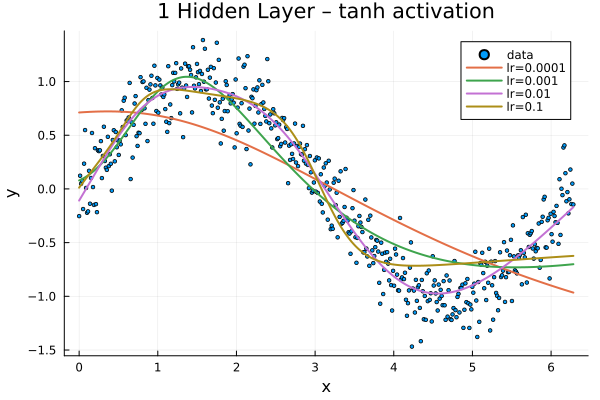

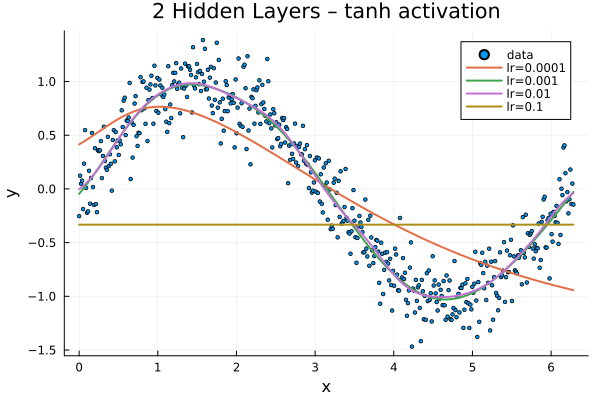

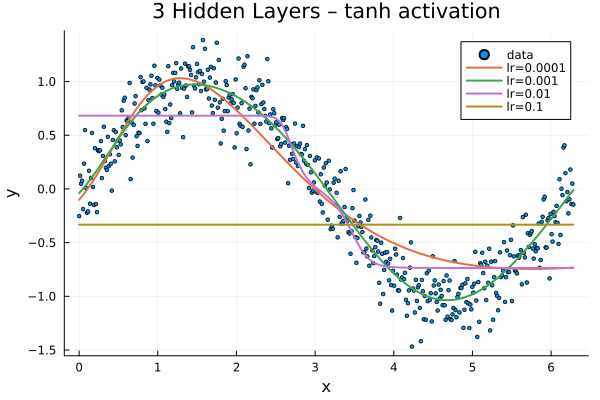

"C:\\Users\\User\\Desktop\\DML_NN\\Julia\\Output\\LearningRate_3Layers.png"

In [21]:
using MLJ, MLJFlux, Flux, DataFrames, Random, PrettyTables, Plots

Random.seed!(7)
n = 500
x = range(0, 2π; length=n)
ϵ = 0.20 .* randn(n)
y = @. sin(x) + ϵ
df = DataFrame(x = collect(x), y = y)
X = select(df, :x)
yv = df.y
xgrid = collect(range(0, 2π; length=800))
Xgrid = DataFrame(x = xgrid)
const n_in = 1
const n_out = 1

function builder_by_activation(activation; n_hidden_layers=1, n_hidden_units=50)
    layers = Any[ Dense(n_in, n_hidden_units, activation) ]
    for _ in 2:n_hidden_layers
        push!(layers, Dense(n_hidden_units, n_hidden_units, activation))
    end
    push!(layers, Dense(n_hidden_units, n_out))
    return MLJFlux.@builder Chain(layers...)
end

function fit_lr(lr; n_hidden_layers=1, n_hidden_units=50)
    builder = builder_by_activation(tanh;
                                    n_hidden_layers=n_hidden_layers,
                                    n_hidden_units=n_hidden_units)
    nn = MLJFlux.NeuralNetworkRegressor(
        builder=builder,
        optimiser=Flux.ADAM(lr),
        epochs=1500,
        batch_size=128,
    )
    mach = machine(nn, X, yv) |> fit!
    yhat_grid = collect(predict(mach, Xgrid))
    mse = mean((collect(predict(mach, X)) .- yv).^2)
    return (lr=lr, mse=mse, yhat=yhat_grid)
end

lrs = [0.0001, 0.001, 0.01, 0.1]
results_1L = [fit_lr(lr; n_hidden_layers=1) for lr in lrs]

results_2L = [fit_lr(lr; n_hidden_layers=2) for lr in lrs]
results_3L = [fit_lr(lr; n_hidden_layers=3) for lr in lrs]

tbl = DataFrame(
    learning_rate = repeat(lrs, inner=1),
    mse_1layer = [r.mse for r in results_1L],
    mse_2layer = [r.mse for r in results_2L],
    mse_3layer = [r.mse for r in results_3L],
)
pretty_table(tbl)

function plot_lr_comparison(results, title_str)
    p = scatter(x, y; ms=2, label="data", xlabel="x", ylabel="y", title=title_str)
    for res in results
        plot!(p, xgrid, res.yhat; lw=2, label="lr=$(res.lr)")
    end
    return p
end

output_path = raw"C:\Users\User\Desktop\DML_NN\Julia\Output"
mkpath(output_path)

p1 = plot_lr_comparison(results_1L, "1 Hidden Layer – tanh activation")
display(p1)
savefig(p1, joinpath(output_path, "LearningRate_1Layer.png"))

p2 = plot_lr_comparison(results_2L, "2 Hidden Layers – tanh activation")
display(p2)
savefig(p2, joinpath(output_path, "LearningRate_2Layers.png"))

p3 = plot_lr_comparison(results_3L, "3 Hidden Layers – tanh activation")
display(p3)
savefig(p3, joinpath(output_path, "LearningRate_3Layers.png"))



### Step 2: Short answer (0.5 pts)

### **Observed Results**

**For 1 hidden layer (50 neurons, `tanh` activation):**  
- $\eta = 0.0001$ → underfits, too slow.  
- $\eta = 0.001$ → best fit, smooth curve close to $\sin(x)$.  
- $\eta = 0.01$ → slightly unstable, overshoots in some regions.  
- $\eta = 0.1$ → diverges early and produces a poor approximation.  

**For 2 hidden layers:**  
- $\eta = 0.001$ still performs best.  
- Higher rates like $\eta = 0.01$ and $\eta = 0.1$ cause flat or erratic curves, showing overfitting or failure to converge.  

**For 3 hidden layers:**  
- The network becomes more sensitive to $\eta$.  
- $\eta = 0.001$ remains stable, while $\eta = 0.01$ and $\eta = 0.1$ lead to partial divergence or plateauing.  

---

### **Conclusion**

> The **optimal learning rate** for this problem is around **$\eta = 0.001$**.  
> As the number of hidden layers increases, **smaller learning rates** are required to maintain stable convergence because gradients become more sensitive in deeper architectures.






